In [71]:
using LimberJack
import LimberJack.TkEisHu

In [74]:
using Interpolations

# Utility: drag-epoch sound horizon from the EH fitting formula (same as inside TkEisHu).
# Returns r_d in Mpc.
function r_drag_EH(cpar::CosmoPar)
    wm = cpar.Ωm * cpar.h^2
    wb = cpar.Ωb * cpar.h^2
    keq    = (7.46e-2) * wm / (cpar.h * cpar.θCMB^2)   # Mpc⁻¹
    zeq    = (2.5e4)   * wm * (cpar.θCMB^-4)
    b1     = 0.313 * (wm^-0.419) * (1 + 0.607 * wm^0.674)
    b2     = 0.238 * wm^0.223
    zd     = 1291 * ((wm^0.251) / (1 + 0.659 * wm^0.828)) * (1 + b1 * wb^b2)
    R_pref = 31.5 * wb * (cpar.θCMB^-4)
    Rd     = R_pref * ((zd + 1) / 1e3)^-1
    Req    = R_pref * (zeq    / 1e3)^-1
    rs = sqrt(1 + Rd) + sqrt(Rd + Req)
    rs /= (1 + sqrt(Req))
    rs  = log(rs)
    rs *= (2 / (3 * keq)) * sqrt(6 / Req)
    return rs  # Mpc
end

"""
    m_shapefit(cosmo, k, k_pivot, Tk_EH_fid)

ShapeFit slope parameter m (Eq. 5.16 of arXiv:2404.07269).

d/d(ln k) of ln[(P_EH/P_prim) / (P_EH_fid/P_prim_fid)] evaluated at k_pivot.

- `k`          : wavenumbers in h Mpc⁻¹  (log-uniformly spaced, e.g. cosmo.settings.ks)
- `k_pivot`    : pivot scale in h Mpc⁻¹  (≈ 0.03 h Mpc⁻¹)
- `Tk_EH_fid`  : T²_EH(k) at fiducial cosmology (from TkEisHu)
"""
function m_shapefit(
    cosmo      :: Cosmology,
    k          :: Vector{Float64},
    k_pivot    :: Float64,
    Tk_EH_fid  :: Vector{Float64},
)
    cpar      = cosmo.cpar
    Pk_pri    = @. cpar.As * (k / k_pivot)^(cpar.ns - 1)
    Tk_EH     = LimberJack.TkEisHu(cpar, k ./ cpar.h)
    log_ratio = @. log(Tk_EH) - log(Tk_EH_fid)
    # cubic_spline_interpolation requires an AbstractRange for the knots
    lnk = range(log(k[1]), log(k[end]), length = length(k))
    itp = cubic_spline_interpolation(lnk, log_ratio, extrapolation_bc = Line())
    δ = 1e-5
    return (itp(log(k_pivot) + δ) - itp(log(k_pivot) - δ)) / (2δ)
end

"""
    A_shapefit(cosmo, k, k_pivot, Pk_pri_fid, Pk_EH_fid, r_d, r_d_fid)

ShapeFit amplitude A = A_sp / A_sp^fid (Eq. 5.15 of arXiv:2404.07269;
Eq. 4.11 of arXiv:2411.12021).

A_sp = (r_d^fid / r_d)³ · P_nw(k_p · r_d^fid / r_d) / P_nw^fid(k_p)

- `r_d`     : drag-epoch sound horizon of the model cosmology (Mpc)
- `r_d_fid` : drag-epoch sound horizon of the fiducial cosmology (Mpc)
"""
function A_shapefit(
    cosmo      :: Cosmology,
    k          :: Vector{Float64},
    k_pivot    :: Float64,
    r_d        :: Float64,
    r_d_fid    :: Float64,
)
    cpar     = cosmo.cpar
    s        = r_d / r_d_fid           
    Tk       = LimberJack.TkEisHu(cpar, k ./ cpar.h)
    Pk       = @. cpar.As * (k / k_pivot)^(cpar.ns - 1) * Tk   # proxy for P_nw

    lnk       = range(log(k[1]), log(k[end]), length = length(k))
    itp_model = cubic_spline_interpolation(lnk, log.(Pk), extrapolation_bc = Line())
    k_eval = k_pivot / s

    return (1/s)^3 * exp(itp_model(log(k_eval)))
end

"""
    fs8_shapefit(fs8, m, A_sp, r_d_fid, h_fid; a_sf)

Step 2: apply the ShapeFit modification (Eq. 5.14 of arXiv:2404.07269;
Eq. 4.10 of arXiv:2411.12021) to a standard f σ_8 value, producing f σ_{s8}.

f σ_{s8} = f σ_8^{ref} · A^{1/2} · exp[ m/(2a) · tanh(a · ln(r_d^{ref}[h_fid⁻¹ Mpc] / (8 h_fid⁻¹ Mpc))) ]

Step 1 (computing the plain f σ_8^{ref} that feeds this) is just
`cosmo_fid.fs8z(z)` — the standard LimberJack growth-rate calculation,
with no ShapeFit modification. This function only applies the correction
on top of that already-computed value.

- `fs8`     : f σ_8 of the reference/fiducial cosmology at the evaluation redshift (step 1 output)
- `m`       : ShapeFit slope parameter (from `m_shapefit`)
- `A`       : ShapeFit amplitude ratio (from `A_shapefit`)
- `r_d_fid` : fiducial drag-epoch sound horizon (Mpc)
- `h_fid`   : h of the fiducial/reference cosmology
- `a_sf`    : ShapeFit 'a' parameter (default 0.6)
"""
function fs8_shapefit(
    fs8     :: Float64,
    m       :: Float64,
    A       :: Float64,
    r_d_fid :: Float64,
    h_fid   :: Float64;
    a_sf    :: Float64 = 0.6,
)
    r_d_fid_hMpc = r_d_fid * h_fid   # r_d^ref expressed in h_fid⁻¹ Mpc
    return fs8 * sqrt(A) * exp(m / (2 * a_sf) * tanh(a_sf * log(r_d_fid_hMpc / 8.0)))
end

fs8_shapefit

In [77]:
cosmo = Cosmology(σ8=0.8, Ωm=0.27, Ωb=0.04)
cosmo_fid = Cosmology()
settings  = cosmo.settings
cpar      = cosmo.cpar
cpar_fid  = cosmo_fid.cpar

k       = settings.ks    # h/Mpc
k_pivot = 0.03           # h/Mpc  (≈ π / r_d^fid for typical ΛCDM)

Tk_EH_fid  = LimberJack.TkEisHu(cpar_fid, k ./ cpar_fid.h)
Pk_pri_fid = @. cpar_fid.As * (k / k_pivot)^(cpar_fid.ns - 1)

r_d_fid = r_drag_EH(cpar_fid)
r_d     = r_drag_EH(cpar)    # same here; differs when model ≠ fiducial
println("r_d^fid = $(round(r_d_fid; digits=2)) Mpc")

# Self-consistency: model = fiducial → m≈0, A≈1, fσ_s8 ≈ fσ_8
z_eff = 0.5

m_sp = m_shapefit(cosmo, k, k_pivot, Tk_EH_fid)
A_sp = A_shapefit(cosmo, k, k_pivot, r_d, r_d_fid)
A_fid = A_shapefit(cosmo_fid, k, k_pivot, r_d_fid, r_d_fid)
A = A_sp / A_fid   # ratio of model/fiducial amplitude

# Step 1: standard f σ_8 of the reference/fiducial cosmology (no ShapeFit modification)
fsigma_8 = cosmo.fs8z(z_eff)
fsigma_8_fid = cosmo_fid.fs8z(z_eff)

# Step 2: apply the ShapeFit modification to turn f σ_8 into f σ_{s8}
fsigma_s8 = fs8_shapefit(fsigma_8, m_sp, A, r_d_fid, cpar_fid.h)

println("m  (≈ 0): ", round(m_sp;   digits=6))
println("A  (≈ 1): ", round(A;       digits=6))
println("fσ_s8 at z=0.5: ", round(fsigma_s8;        digits=6))
println("fσ_8  at z=0.5: ", round(fsigma_8; digits=6))

r_d^fid = 102.6 Mpc
m  (≈ 0): 0.037223
A  (≈ 1): 0.823759
fσ_s8 at z=0.5: 0.334352
fσ_8  at z=0.5: 0.358698


In [87]:
## fsigma8 Data
z = [0.33, 0.51, 0.71, 0.93, 1.32, 1.49]
fsigma8_data = [0.38, 0.52, 0.47, 0.42, 0.38, 0.43]
fsigma8_err = [0.09, 0.06, 0.06, 0.04, 0.04, 0.045];

In [79]:
using Printf

# Step 1: standard f σ_8(z) predicted by our (fiducial) cosmology at each data redshift
model_fsigma_8 = [cosmo.fs8z(zi) for zi in z]

# Step 2: apply the ShapeFit modification (Eq. 5.14) using the *quoted* m(z) values.
# A is not provided in the data, so we fix A = 1 (no extra amplitude rescaling) —
# only the shape (m) modification is applied on top of the model f σ_8.
fs8_s8_from_m = [fs8_shapefit(model_fsigma_8[i], m_data[i], A, r_d_fid, cpar_fid.h)
                 for i in eachindex(z)]

resid_fs8    = (model_fsigma_8    .- fsigma8_data) ./ fsigma8_err
resid_fs8_s8 = (fs8_s8_from_m .- fsigma8_data) ./ fsigma8_err

println(rpad("z", 6), rpad("fσ8_data", 10), rpad("err", 8), rpad("fσ8_model", 11),
        rpad("Δ/σ", 8), rpad("m_data", 9), rpad("fσ_s8(m)", 10), "Δ/σ")
for i in eachindex(z)
    @printf("%.2f  %.4f    %.3f   %.4f     %6.2f   %7.4f  %.4f    %6.2f\n",
            z[i], fsigma8_data[i], fsigma8_err[i], model_fsigma_8[i], resid_fs8[i],
            m_data[i], fs8_s8_from_m[i], resid_fs8_s8[i])
end

println()
println("χ² (model fσ8 vs data):        ", round(sum(resid_fs8 .^ 2); digits=3))
println("χ² (fσ_s8 from m vs data):     ", round(sum(resid_fs8_s8 .^ 2); digits=3))

z     fσ8_data  err     fσ8_model  Δ/σ     m_data   fσ_s8(m)  Δ/σ
0.33  0.3800    0.090   0.3669      -0.15   -0.0313  0.3256     -0.60
0.51  0.5200    0.060   0.3578      -2.70    0.0278  0.3313     -3.14
0.71  0.4700    0.060   0.3339      -2.27    0.0466  0.3133     -2.61
0.93  0.4200    0.040   0.2974      -3.07   -0.0246  0.2652     -3.87
1.32  0.3800    0.040   0.2208      -3.98    0.0599  0.2092     -4.27
1.49  0.4300    0.045   0.1858      -5.43    0.0645  0.1766     -5.63

χ² (model fσ8 vs data):        67.165
χ² (fσ_s8 from m vs data):     82.004


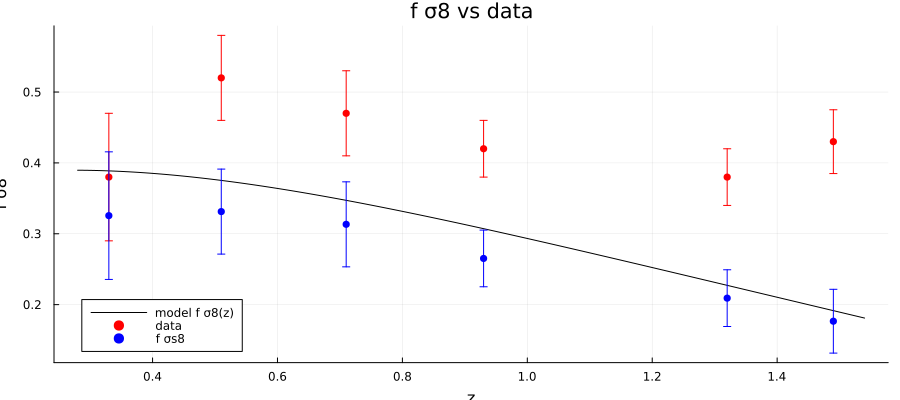

In [86]:
using Plots

# Smooth model fσ8(z) curve for reference in both panels
z_grid    = range(minimum(z) - 0.05, maximum(z) + 0.05, length = 200)
fs8_curve = [cosmo_fid.fs8z(zi) for zi in z_grid]

p1 = plot(z_grid, fs8_curve, label = "model f σ8(z)", lc = :black,
          xlabel = "z", ylabel = "f σ8", title = "f σ8 vs data", legend = :bottomleft)
scatter!(p1, z, fsigma8_data, yerr = fsigma8_err, label = "data",
         mc = :red, msc = :red, ms = 4)
scatter!(p1, z, fs8_s8_from_m, yerr = fsigma8_err, label = "f σs8",
         mc = :blue, msc = :blue, ms = 4)

plot(p1, layout = (1, 1), size = (900, 400))